In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler


2026-03-03 13:26:52.688531: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 13:26:52.689174: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 13:26:52.782870: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 13:26:54.884597: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
from pathlib import Path

csv_path = Path("climate_data (2).csv")
if not csv_path.exists():
	csv_path = Path("/home/haze/Code/Green_AI_shit/lab2/climate_data (2).csv")

data = pd.read_csv(csv_path)

In [3]:
X = data.drop(columns=["Energy Consumption"])
y = data["Energy Consumption"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/home/haze/Code/Green_AI_shit/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-03 13:27:42.892827: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # Use part of the training set for validation
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3033322.2500 - mae: 1518.2493 - val_loss: 2872645.5000 - val_mae: 1475.6417
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2294144.0000 - mae: 1298.0601 - val_loss: 1535735.2500 - val_mae: 1057.3069
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 771326.0000 - mae: 717.9084 - val_loss: 221940.2188 - val_mae: 407.4241
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 84335.2578 - mae: 236.6479 - val_loss: 32860.6250 - val_mae: 144.4259
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 28315.8027 - mae: 127.3429 - val_loss: 23589.3633 - val_mae: 117.3743
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 23182.7168 - mae: 116.5188 - val_loss: 21408.6758 - val_mae: 114.4194
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 21369.5234 - mae: 114.2672 - val_loss: 20467.2578 - val_mae: 112.8304
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20338.0098 - mae

In [8]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 164.5846 - mae: 10.0695
Test Loss: 164.58456420898438, Test MAE: 10.069466590881348


In [9]:
predictions = model.predict(X_test)
print(predictions[:5])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[1150.9874 ]
 [2341.4866 ]
 [ 216.36548]
 [1731.0863 ]
 [2091.864  ]]


In [10]:
print("Predictions:",
predictions [:5])
print("Actual Values:"
,
y_test[:5].values)

Predictions: [[1150.9874 ]
 [2341.4866 ]
 [ 216.36548]
 [1731.0863 ]
 [2091.864  ]]
Actual Values: [1148.70560487 2328.94848405  213.59189032 1719.90776768 2114.25192812]


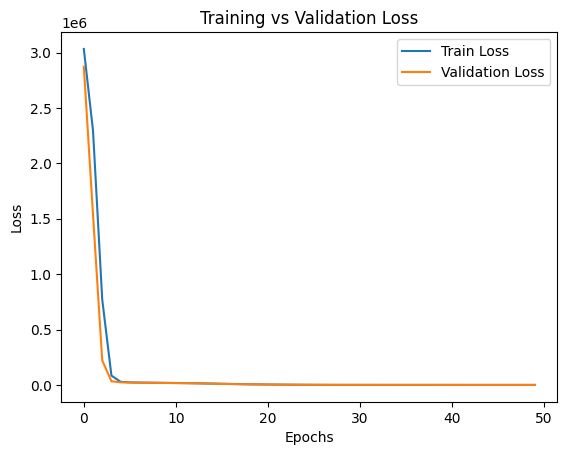

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()